##Retrieve File Location

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import shutil
import random
import pathlib
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# original extracted dataset
original_dir = pathlib.Path("/content/drive/MyDrive/Colab Notebooks/cats_vs_dogs_small")

# new Question 1 dataset
base_dir = pathlib.Path("/content/drive/MyDrive/Colab Notebooks/q1_cats_vs_dogs")

# remove old folder if it exists
if base_dir.exists():
    shutil.rmtree(base_dir)

# create folder structure
for split in ["train", "validation", "test"]:
    for category in ["cats", "dogs"]:
        os.makedirs(base_dir / split / category)

random.seed(42)

def copy_random_images(src_folder, dst_folder, n):
    files = os.listdir(src_folder)
    sampled_files = random.sample(files, n)
    for fname in sampled_files:
        shutil.copy(src_folder / fname, dst_folder / fname)


copy_random_images(original_dir / "train" / "cats", base_dir / "train" / "cats", 500)
copy_random_images(original_dir / "train" / "dogs", base_dir / "train" / "dogs", 500)


copy_random_images(original_dir / "validation" / "cats", base_dir / "validation" / "cats", 250)
copy_random_images(original_dir / "validation" / "dogs", base_dir / "validation" / "dogs", 250)


copy_random_images(original_dir / "test" / "cats", base_dir / "test" / "cats", 250)
copy_random_images(original_dir / "test" / "dogs", base_dir / "test" / "dogs", 250)


print("Train cats:", len(os.listdir(base_dir / "train" / "cats")))
print("Train dogs:", len(os.listdir(base_dir / "train" / "dogs")))
print("Validation cats:", len(os.listdir(base_dir / "validation" / "cats")))
print("Validation dogs:", len(os.listdir(base_dir / "validation" / "dogs")))
print("Test cats:", len(os.listdir(base_dir / "test" / "cats")))
print("Test dogs:", len(os.listdir(base_dir / "test" / "dogs")))


Train cats: 500
Train dogs: 500
Validation cats: 250
Validation dogs: 250
Test cats: 250
Test dogs: 250


##Loading Datasets

In [3]:

train_dataset = image_dataset_from_directory(
    base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 1000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


##Question 1
Intializing a small convnet, Using Data Augmentation

In [4]:


data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [ ]:
model.summary()

Add callbacks,Fit model

In [5]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 253ms/step - accuracy: 0.5150 - loss: 0.8097 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.4900 - loss: 0.6940 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/step - accuracy: 0.5140 - loss: 0.6956 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.5130 - loss: 0.6946 - val_accuracy: 0.5460 - val_loss: 0.6913
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.5090 - loss: 0.6925 - val_accuracy: 0.5080 - val_loss: 0.6892
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.5770 - loss: 0.6846 - val_accuracy: 0.5900 - val_loss: 0.6710
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.5690 - loss: 0.6807 - val_accuracy: 0.6020 - val_loss: 0.6782
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 213ms/step - accuracy: 0.5880 - loss: 0.6755 - val_accuracy: 

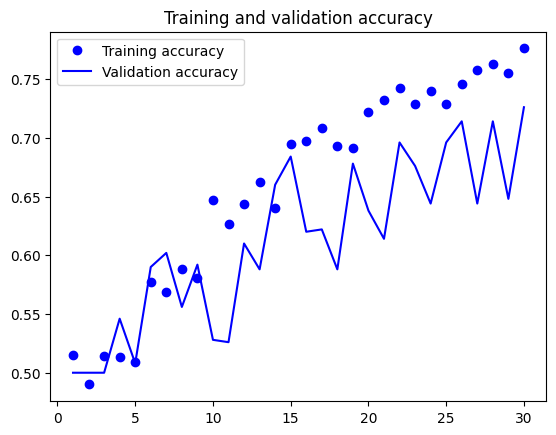

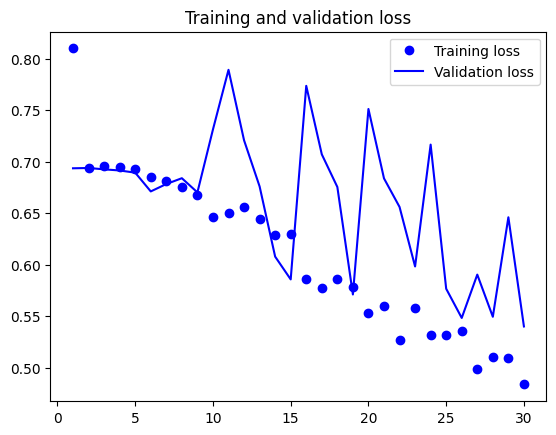

In [6]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Evaluating the model

In [7]:
test_model = keras.models.load_model(
    "convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.7080 - loss: 0.6208
Test accuracy: 0.708


##Question 2 & 3

In [8]:

# original full small dataset
original_dir = pathlib.Path("/content/drive/MyDrive/Colab Notebooks/cats_vs_dogs_small")

# parent Q2 folder
q2_dir = pathlib.Path("/content/drive/MyDrive/Colab Notebooks/q2_samples")

random.seed(42)

def make_dataset_folder(base_dir, train_per_class, val_per_class=250, test_per_class=250):

    if base_dir.exists():
        shutil.rmtree(base_dir)


    for split in ["train", "validation", "test"]:
        for category in ["cats", "dogs"]:
            os.makedirs(base_dir / split / category)

    def copy_random_images(src_folder, dst_folder, n):
        files = os.listdir(src_folder)
        sampled_files = random.sample(files, n)
        for fname in sampled_files:
            shutil.copy(src_folder / fname, dst_folder / fname)


    copy_random_images(original_dir / "train" / "cats", base_dir / "train" / "cats", train_per_class)
    copy_random_images(original_dir / "train" / "dogs", base_dir / "train" / "dogs", train_per_class)


    copy_random_images(original_dir / "validation" / "cats", base_dir / "validation" / "cats", val_per_class)
    copy_random_images(original_dir / "validation" / "dogs", base_dir / "validation" / "dogs", val_per_class)


    copy_random_images(original_dir / "test" / "cats", base_dir / "test" / "cats", test_per_class)
    copy_random_images(original_dir / "test" / "dogs", base_dir / "test" / "dogs", test_per_class)

    print(f"Created: {base_dir}")
    print("Train cats:", len(os.listdir(base_dir / "train" / "cats")))
    print("Train dogs:", len(os.listdir(base_dir / "train" / "dogs")))
    print("Validation cats:", len(os.listdir(base_dir / "validation" / "cats")))
    print("Validation dogs:", len(os.listdir(base_dir / "validation" / "dogs")))
    print("Test cats:", len(os.listdir(base_dir / "test" / "cats")))
    print("Test dogs:", len(os.listdir(base_dir / "test" / "dogs")))
    print("-" * 40)

# Q2 option 1: 750 cats + 750 dogs = 1500 train
make_dataset_folder(q2_dir / "q2_1500", train_per_class=750)

# Q2 option 2: 1000 cats + 1000 dogs = 2000 train
make_dataset_folder(q2_dir / "q2_2000", train_per_class=1000)

Created: /content/drive/MyDrive/Colab Notebooks/q2_samples/q2_1500
Train cats: 750
Train dogs: 750
Validation cats: 250
Validation dogs: 250
Test cats: 250
Test dogs: 250
----------------------------------------
Created: /content/drive/MyDrive/Colab Notebooks/q2_samples/q2_2000
Train cats: 1000
Train dogs: 1000
Validation cats: 250
Validation dogs: 250
Test cats: 250
Test dogs: 250
----------------------------------------


In [9]:
train_dataset2_1500 = image_dataset_from_directory(
    q2_dir / "q2_1500" / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset2_1500 = image_dataset_from_directory(
    q2_dir / "q2_1500" / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset2_1500 = image_dataset_from_directory(
    q2_dir / "q2_1500" / "test",
    image_size=(180, 180),
    batch_size=32)


train_dataset2_2000 = image_dataset_from_directory(
    q2_dir / "q2_2000" / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset2_2000 = image_dataset_from_directory(
    q2_dir / "q2_2000" / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset2_2000 = image_dataset_from_directory(
    q2_dir / "q2_2000" / "test",
    image_size=(180, 180),
    batch_size=32)

Found 1500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [10]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [11]:
callbacks2_1500 = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_q2_1500.keras",
        save_best_only=True,
        monitor="val_loss")
]
callbacks2_2000 = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_q2_2000.keras",
        save_best_only=True,
        monitor="val_loss")
]
history2_1500 = model.fit(
    train_dataset2_1500,
    epochs=30,
    validation_data=validation_dataset2_1500,
    callbacks=callbacks2_1500)

history2_2000 = model.fit(
    train_dataset2_2000,
    epochs=30,
    validation_data=validation_dataset2_2000,
    callbacks=callbacks2_2000)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step - accuracy: 0.4887 - loss: 0.7097 - val_accuracy: 0.5080 - val_loss: 0.6925
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - accuracy: 0.4987 - loss: 0.6947 - val_accuracy: 0.5680 - val_loss: 0.6926
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - accuracy: 0.4967 - loss: 0.6939 - val_accuracy: 0.5080 - val_loss: 0.6922
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - accuracy: 0.5020 - loss: 0.6940 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 0.5393 - loss: 0.6896 - val_accuracy: 0.5020 - val_loss: 0.6984
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - accuracy: 0.6100 - loss: 0.6758 - val_accuracy: 0.5880 - val_loss: 0.6654
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.6113 - loss: 0.6585 - val_accuracy: 0.5580 - val_loss: 0.6709
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.6240 - loss: 0.6523 - val_accuracy:

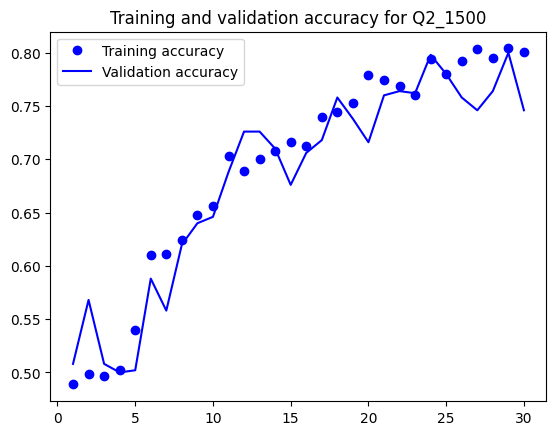

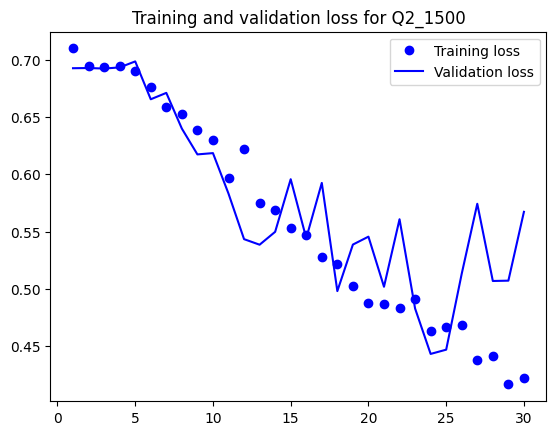

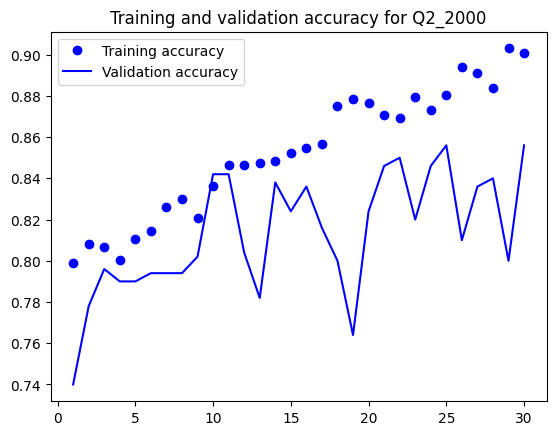

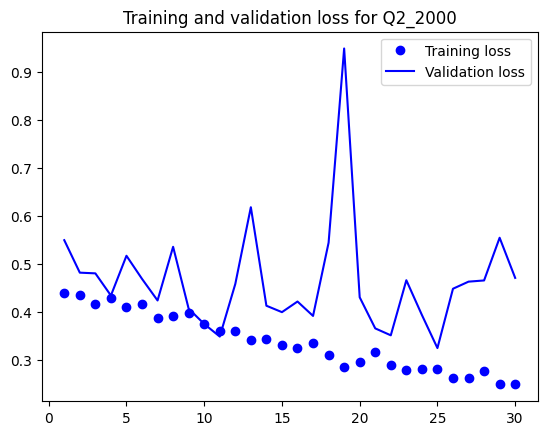

In [12]:
accuracy = history2_1500.history["accuracy"]
val_accuracy = history2_1500.history["val_accuracy"]
loss = history2_1500.history["loss"]
val_loss = history2_1500.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy for Q2_1500")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss for Q2_1500")
plt.legend()
plt.show()

accuracy = history2_2000.history["accuracy"]
val_accuracy = history2_2000.history["val_accuracy"]
loss = history2_2000.history["loss"]
val_loss = history2_2000.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy for Q2_2000")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss for Q2_2000")
plt.legend()
plt.show()

In [13]:
test_model_original = keras.models.load_model(
    "convnet_from_scratch.keras")
test_loss_original, test_acc_original = test_model_original.evaluate(test_dataset)
print(f"Test accuracy (1000-sample model): {test_acc_original:.3f}")

test_model_1500 = keras.models.load_model(
    "convnet_from_scratch_q2_1500.keras")
test_loss_1500, test_acc_1500 = test_model_1500.evaluate(test_dataset2_1500)
print(f"Test accuracy (1500-sample model): {test_acc_1500:.3f}")

test_model_2000 = keras.models.load_model(
    "convnet_from_scratch_q2_2000.keras")
test_loss_2000, test_acc_2000 = test_model_2000.evaluate(test_dataset2_2000)
print(f"Test accuracy (2000-sample model): {test_acc_2000:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.7080 - loss: 0.6208
Test accuracy (1000-sample model): 0.708
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.7540 - loss: 0.5530
Test accuracy (1500-sample model): 0.754
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.8280 - loss: 0.4332
Test accuracy (2000-sample model): 0.828


In [14]:
print(f"\nTest accuracy (1000-sample model): {test_acc_original:.3f}")
print(f"Test accuracy (1500-sample model): {test_acc_1500:.3f}")
print(f"Test accuracy (2000-sample model): {test_acc_2000:.3f}")

accuracies = {
    "1000 samples": test_acc_original,
    "1500 samples": test_acc_1500,
    "2000 samples": test_acc_2000
}

best_sample_size = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_sample_size]

print(f"\nConclusion: The model trained with {best_sample_size} yielded the best performance with a test accuracy of {best_accuracy:.3f}.")


Test accuracy (1000-sample model): 0.708
Test accuracy (1500-sample model): 0.754
Test accuracy (2000-sample model): 0.828

Conclusion: The model trained with 2000 samples yielded the best performance with a test accuracy of 0.828.


##Question 4

In [15]:
conv_base  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [16]:
import numpy as np

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels =  get_features_and_labels(train_dataset)
val_features, val_labels =  get_features_and_labels(validation_dataset)
test_features, test_labels =  get_features_and_labels(test_dataset)

train_features.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

(1000, 5, 5, 512)

In [17]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step - accuracy: 0.6930 - loss: 5.1372 - val_accuracy: 0.9020 - val_loss: 0.8557
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - accuracy: 0.8090 - loss: 2.2564 - val_accuracy: 0.9500 - val_loss: 0.4882
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.8540 - loss: 1.5805 - val_accuracy: 0.9580 - val_loss: 0.3612
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 240ms/step - accuracy: 0.9060 - loss: 0.7504 - val_accuracy: 0.9480 - val_loss: 0.3404
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 239ms/step - accuracy: 0.8990 - loss: 0.6719 - val_accuracy: 0.9680 - val_loss: 0.2763
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.9170 - loss: 0.4958 - val_accuracy: 0.9660 - val_loss: 0.2167
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - accuracy: 0.9460 - loss: 0.3451 - val_accuracy: 0.9700 - val_loss: 0.2166
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.9360 - loss: 0.3631 - val_accuracy:

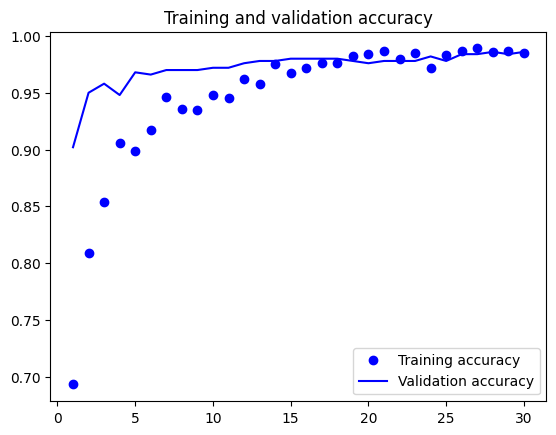

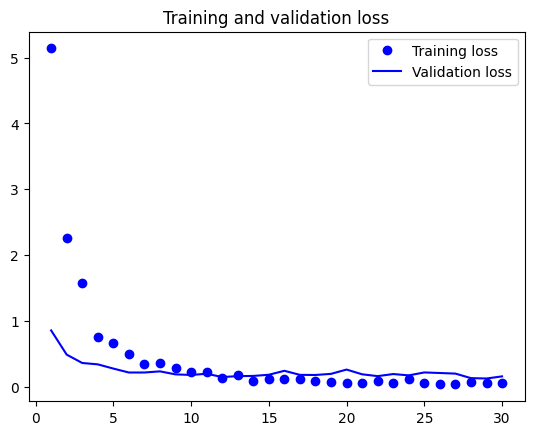

In [18]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [28]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9540 - loss: 0.3845
Test accuracy: 0.954


##1500 & 2000 traing sample size on pretrained model

In [20]:
conv_base_1500  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base_1500.trainable = True
for layer in conv_base_1500.layers[:-4]:
    layer.trainable = False

conv_base_1500.summary()

conv_base_2000  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base_2000.trainable = True
for layer in conv_base_2000.layers[:-4]:
    layer.trainable = False

conv_base_2000.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [21]:

train_features_1500, train_labels_1500 =  get_features_and_labels(train_dataset2_1500)
val_features_1500, val_labels_1500 =  get_features_and_labels(validation_dataset2_1500)
test_features_1500, test_labels_1500 =  get_features_and_labels(test_dataset2_1500)

train_features_1500.shape

train_features_2000, train_labels_2000 =  get_features_and_labels(train_dataset2_2000)
val_features_2000, val_labels_2000 =  get_features_and_labels(validation_dataset2_2000)
test_features_2000, test_labels_2000 =  get_features_and_labels(test_dataset2_2000)

train_features_2000.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

(2000, 5, 5, 512)

In [25]:

callbacks2_1500 = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning_1500.keras",
        save_best_only=True,
        monitor="val_loss")
]
history2_1500 = model.fit(
    train_dataset2_1500,
    epochs=30,
    validation_data =validation_dataset,
    callbacks=callbacks2_1500)

callbacks2_2000 = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning_2000.keras",
        save_best_only=True,
        monitor="val_loss")
]
history2_2000 = model.fit(
    train_dataset2_2000,
    epochs=30,
    validation_data =validation_dataset,
    callbacks=callbacks2_2000)



Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.9967 - loss: 0.0164 - val_accuracy: 0.9840 - val_loss: 0.1595
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.9980 - loss: 0.0025 - val_accuracy: 0.9840 - val_loss: 0.1659
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.9980 - loss: 0.0040 - val_accuracy: 0.9840 - val_loss: 0.1560
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.9987 - loss: 0.0017 - val_accuracy: 0.9820 - val_loss: 0.2353
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.9973 - loss: 0.0154 - val_accuracy: 0.9840 - val_loss: 0.1985
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.9820 - val_loss: 0.1200
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.9987 - loss: 0.0071 - val_accuracy: 0.9820 - val_loss: 0.1768
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step - accuracy: 1.0000 - loss: 7.1209e-04 - val_accu

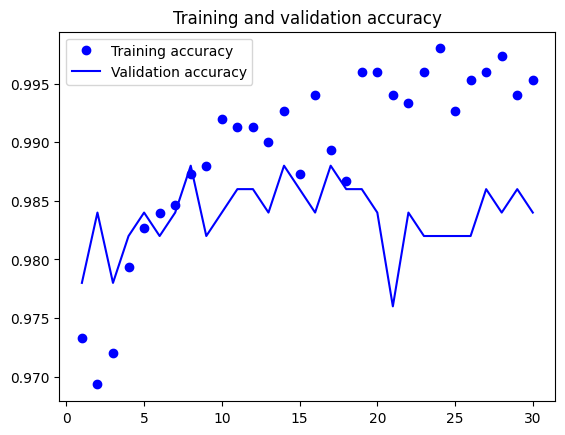

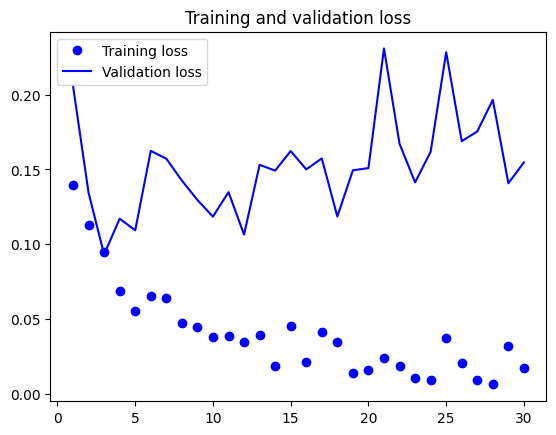

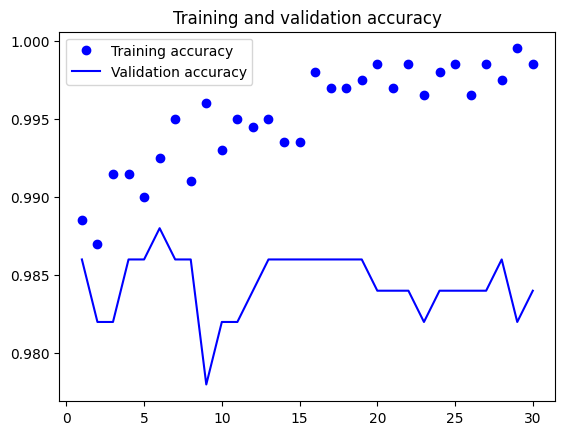

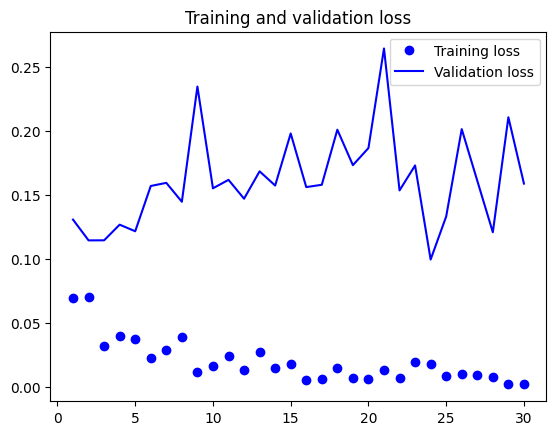

In [24]:
acc = history2_1500.history["accuracy"]
val_acc = history2_1500.history["val_accuracy"]
loss = history2_1500.history["loss"]
val_loss = history2_1500.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

acc = history2_2000.history["accuracy"]
val_acc = history2_2000.history["val_accuracy"]
loss = history2_2000.history["loss"]
val_loss = history2_2000.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [32]:
model2_1500 = keras.models.load_model("fine_tuning_1500.keras")
test_loss2_1500, test_acc2_1500 = model.evaluate(test_dataset2_1500)
print(f"Test accuracy: {test_acc2_1500:.3f}")

model2_2000 = keras.models.load_model("fine_tuning_2000.keras")
test_loss2_2000, test_acc2_2000 = model.evaluate(test_dataset2_2000)
print(f"Test accuracy: {test_acc2_2000:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.9660 - loss: 0.2616
Test accuracy: 0.966
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.9480 - loss: 0.4299
Test accuracy: 0.948


In [29]:
print(f"\nTest accuracy (1000-sample model): {test_acc:.3f}")
print(f"Test accuracy (1500-sample model): {test_acc2_1500:.3f}")
print(f"Test accuracy (2000-sample model): {test_acc2_2000:.3f}")

accuracies = {
    "1000 samples": test_acc,
    "1500 samples": test_acc2_1500,
    "2000 samples": test_acc2_2000
}

best_sample_size = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_sample_size]

print(f"\nConclusion: The model trained with {best_sample_size} yielded the best performance with a test accuracy of {best_accuracy:.3f}.")


Test accuracy (1000-sample model): 0.954
Test accuracy (1500-sample model): 0.982
Test accuracy (2000-sample model): 0.964

Conclusion: The model trained with 1500 samples yielded the best performance with a test accuracy of 0.982.
